# Top+Side View Volume Estimation
# Feature Extractor with Trainable Last Stage + POV Fusion + Regression Head

This notebook trains and evaluates different combinations of feature extractors with unfrozen last stage, and regression heads on the top+side dataset. Uses concat fusion strategy.


In [1]:
import datetime
import json
import warnings
from src.training_and_evaluation import *
from src.trainable_pipelines import *

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)

/home/lenka-hake/Documents/CV/ComputerVisionProject/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Setup

In [2]:
LAST_LAYER_OUTER_SPLITS = 3
LAST_LAYER_INNER_SPLITS = 3

LAST_LAYER_BACKBONE_NAMES = [
    # "densenet121",
    "vit_b_16"
]

LAST_LAYER_FUSION_NAMES = [
    "concat"
]

LAST_LAYER_REGRESSION_MODEL_CONFIGS = {
    # "linear": list(ParameterGrid({
    #     "lr_backbone": [1e-4],
    #     # "lr_head": [1e-3],
    #     # "weight_decay": [1e-3],
    #     "lr_head": [1e-3, 3e-4],
    #     "weight_decay": [1e-2, 1e-3],
    # })),
    "mlp": list(ParameterGrid({
        "hidden_dims": [(64, 32)],
        "dropout": [0.0],
        "lr_backbone": [1e-4],
        "lr_head": [1e-3, 3e-4],
        "weight_decay": [1e-2, 1e-3],
    })),
}

## Load Data

In [3]:
samples, image_paths = load_image_paths(CSV_PATH, TOP_FOLDER, SIDE_FOLDER)
print("Samples shape:", samples.shape)
display(samples[["exp_id", "volume", "top_path", "side_path"]].head(8))

Samples shape: (420, 24)


,exp_id,volume,top_path,side_path
0,1,1.06,photos/top_view_images/P2260331.JPG,photos/side_view_images/P2260685.JPG
1,1,2.12,photos/top_view_images/P2260332.JPG,photos/side_view_images/P2260686.JPG
2,1,3.18,photos/top_view_images/P2260333.JPG,photos/side_view_images/P2260687.JPG
3,1,4.24,photos/top_view_images/P2260334.JPG,photos/side_view_images/P2260688.JPG
4,2,1.06,photos/top_view_images/P2260335.JPG,photos/side_view_images/P2260689.JPG
5,2,2.12,photos/top_view_images/P2260336.JPG,photos/side_view_images/P2260690.JPG
6,2,3.18,photos/top_view_images/P2260337.JPG,photos/side_view_images/P2260692.JPG
7,2,4.24,photos/top_view_images/P2260339.JPG,photos/side_view_images/P2260693.JPG


## Show Regression Model Configurations

In [4]:
print("Grid sizes per head:")
for name, grid in LAST_LAYER_REGRESSION_MODEL_CONFIGS.items():
    n = len(grid)
    print(f"  {name:10s}: {n:4d}")

Grid sizes per head:
  mlp       :    4


## Nested CV Evaluation (split by experiment IDs)

In [5]:
all_results = []
nested_artifacts = {}

for backbone_name in LAST_LAYER_BACKBONE_NAMES:
    for fusion_name in LAST_LAYER_FUSION_NAMES:
        print(f"\n{'#'*90}")
        print(f"Evaluating backbone={backbone_name}, fusion={fusion_name}")
        print(f"{'#'*90}")

        nested_results, oof_predictions, training_histories = run_end_to_end_nested_cv(
            samples_df=samples,
            backbone_name=backbone_name,
            fusion_name=fusion_name,
            head_configs=LAST_LAYER_REGRESSION_MODEL_CONFIGS,
            outer_splits=LAST_LAYER_OUTER_SPLITS,
            inner_splits=LAST_LAYER_INNER_SPLITS,
            batch_size=BATCH_SIZE,
            max_epochs=MAX_EPOCHS,
            device=DEVICE,
            side_mask_paths=SIDE_ROI_MASKS,
            top_mask_paths=TOP_ROI_MASKS,
            patience=PATIENCE,
            min_delta=0.0
        )

        summary_df = summarise_nested_results(nested_results, backbone_name, fusion_name)
        all_results.append(summary_df)
        nested_artifacts[(backbone_name, fusion_name)] = {
            "y": samples["volume"].to_numpy(dtype=float),
            "groups": samples["exp_id"].to_numpy(),
            "nested_results": nested_results,
            "oof_predictions": oof_predictions,
            "training_histories": training_histories,
        }

results_df = pd.concat(all_results, ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)


##########################################################################################
Evaluating backbone=vit_b_16, fusion=concat
##########################################################################################

GroupKFold | vit_b_16 | concat | mlp


Outer Folds:   0%|          | 0/3 [00:00<?, ?it/s]
# Configs | Outer Fold 1/3:   0%|          | 0/4 [00:00<?, ?it/s]

## Inner Folds | Outer Fold 1/3 | Config 1/4:   0%|          | 0/3 [00:00<?, ?it/s]


### Epochs:   0%|          | 0/20 [00:00<?, ?it/s]


### Epochs:   0%|          | 0/20 [01:38<?, ?it/s, best_val_mae=inf, train_loss=2.2977, val_mae=0.6921]


### Epochs:   5%|▌         | 1/20 [01:38<31:05, 98.16s/it, best_val_mae=inf, train_loss=2.2977, val_mae=0.6921]


### Epochs:   5%|▌         | 1/20 [03:36<31:05, 98.16s/it, best_val_mae=0.6921, train_loss=0.4381, val_mae=0.4324]


### Epochs:  10%|█         | 2/20 [03:36<32:57, 109.85s/it, best_val_mae=0.6921, train_loss=0.4381, val_mae=0.4324]


### Epochs:  10%|█         | 2/20 [05:31<32:57, 109.85s/it, best_val_mae=0.4324, train_loss=0.2195, val_mae=0.4243]


### Epochs:  15%|█▌        | 3/20 [05:31<31:46, 112.16s/it, best_val_mae=0.4324, train_loss=0.2195, val_mae=0.4243]


### Epochs:  15%|█▌        | 3/20 [07:29<31:46, 112.

Early stopping at epoch 19: train_loss=0.0012, val_mae=0.3224




## Inner Folds | Outer Fold 1/3 | Config 3/4:   0%|          | 0/3 [00:00<?, ?it/s]


### Epochs:   0%|          | 0/20 [00:00<?, ?it/s]


### Epochs:   0%|          | 0/20 [01:37<?, ?it/s, best_val_mae=inf, train_loss=3.4270, val_mae=0.9705]


### Epochs:   5%|▌         | 1/20 [01:37<31:00, 97.92s/it, best_val_mae=inf, train_loss=3.4270, val_mae=0.9705]


### Epochs:   5%|▌         | 1/20 [03:21<31:00, 97.92s/it, best_val_mae=0.9705, train_loss=1.0964, val_mae=0.7327]


### Epochs:  10%|█         | 2/20 [03:21<30:20, 101.15s/it, best_val_mae=0.9705, train_loss=1.0964, val_mae=0.7327]


### Epochs:  10%|█         | 2/20 [04:52<30:20, 101.15s/it, best_val_mae=0.7327, train_loss=0.4792, val_mae=0.4515]


### Epochs:  15%|█▌        | 3/20 [04:52<27:21, 96.53s/it, best_val_mae=0.7327, train_loss=0.4792, val_mae=0.4515] 


### Epochs:  15%|█▌        | 3/20 [06:34<27:21, 96.53s/it, best_val_mae=0.4515, train_loss=0.2852, val_mae=0.4078]


### Epochs:  20%|██        | 4/20 [06:34<26:21, 98.

Early stopping at epoch 19: train_loss=0.0029, val_mae=0.2988


...

Early stopping at epoch 19: train_loss=0.0179, val_mae=0.3107




## Inner Folds | Outer Fold 3/3 | Config 4/4:   0%|          | 0/3 [00:00<?, ?it/s]


### Epochs:   0%|          | 0/20 [00:00<?, ?it/s]


### Epochs:   0%|          | 0/20 [01:41<?, ?it/s, best_val_mae=inf, train_loss=2.8762, val_mae=0.8300]


### Epochs:   5%|▌         | 1/20 [01:41<32:03, 101.26s/it, best_val_mae=inf, train_loss=2.8762, val_mae=0.8300]


### Epochs:   5%|▌         | 1/20 [03:12<32:03, 101.26s/it, best_val_mae=0.8300, train_loss=0.5359, val_mae=0.4374]


### Epochs:  10%|█         | 2/20 [03:12<28:35, 95.30s/it, best_val_mae=0.8300, train_loss=0.5359, val_mae=0.4374] 


### Epochs:  10%|█         | 2/20 [04:54<28:35, 95.30s/it, best_val_mae=0.4374, train_loss=0.2017, val_mae=0.3949]


### Epochs:  15%|█▌        | 3/20 [04:54<27:50, 98.25s/it, best_val_mae=0.4374, train_loss=0.2017, val_mae=0.3949]


### Epochs:  15%|█▌        | 3/20 [06:24<27:50, 98.25s/it, best_val_mae=0.3949, train_loss=0.1420, val_mae=0.3554]


### Epochs:  20%|██        | 4/20 [06:24<25:22, 95.

Early stopping at epoch 15: train_loss=0.0140, val_mae=0.2992





### Epochs:   0%|          | 0/20 [00:00<?, ?it/s]


### Epochs:   0%|          | 0/20 [01:38<?, ?it/s, best_val_mae=inf, train_loss=3.1125, val_mae=0.9945]


### Epochs:   5%|▌         | 1/20 [01:38<31:19, 98.92s/it, best_val_mae=inf, train_loss=3.1125, val_mae=0.9945]


### Epochs:   5%|▌         | 1/20 [03:22<31:19, 98.92s/it, best_val_mae=0.9945, train_loss=0.8143, val_mae=0.5272]


### Epochs:  10%|█         | 2/20 [03:22<30:33, 101.87s/it, best_val_mae=0.9945, train_loss=0.8143, val_mae=0.5272]


### Epochs:  10%|█         | 2/20 [04:53<30:33, 101.87s/it, best_val_mae=0.5272, train_loss=0.3242, val_mae=0.4248]


### Epochs:  15%|█▌        | 3/20 [04:53<27:24, 96.72s/it, best_val_mae=0.5272, train_loss=0.3242, val_mae=0.4248] 


### Epochs:  15%|█▌        | 3/20 [06:34<27:24, 96.72s/it, best_val_mae=0.4248, train_loss=0.1617, val_mae=0.3690]


### Epochs:  20%|██        | 4/20 [06:34<26:16, 98.54s/it, best_val_mae=0.4248, train_loss=0.1617, val_mae=0.3690]


### Epochs:  20%|██

Outer Fold 3: MAE=0.318, RMSE=0.419, R2=0.8758944385723978, best={'dropout': 0.0, 'hidden_dims': (64, 32), 'lr_backbone': 0.0001, 'lr_head': 0.0003, 'weight_decay': 0.01}


## Add Dummy Mean Predictions for Comparison

In [6]:
dummy_pred = np.full(len(samples), samples["volume"].mean(), dtype=float)
dummy_mae = mean_absolute_error(samples["volume"], dummy_pred)
dummy_mse = mean_squared_error(samples["volume"], dummy_pred)
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(samples["volume"], dummy_pred)

dummy_row = pd.DataFrame([{
    "backbone": "dummy_mean",
    "fusion": "dummy_mean",
    "regressor": "dummy_mean",
    "cv_mae_mean": dummy_mae,
    "cv_mae_std": 0.0,
    "cv_mse_mean": dummy_mse,
    "cv_mse_std": 0.0,
    "cv_rmse_mean": dummy_rmse,
    "cv_rmse_std": 0.0,
    "cv_r2_mean": dummy_r2,
    "cv_r2_std": 0.0,
}])

results_df = pd.concat([results_df, dummy_row], ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)

## Show Selected Hyperparameters

In [7]:
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    print(f"\n{'='*90}")
    print(f"backbone={backbone_name}, fusion={fusion_name}")
    print(f"{'='*90}")
    for head_name, folds in artifact["nested_results"].items():
        has_params = any(f["best_params"] for f in folds)
        if not has_params:
            continue
        print(head_name)
        for f in folds:
            print(f"  Fold {f['fold']}: {f['best_params']}")
        print()


backbone=vit_b_16, fusion=concat
mlp
  Fold 1: {'dropout': 0.0, 'hidden_dims': (64, 32), 'lr_backbone': 0.0001, 'lr_head': 0.0003, 'weight_decay': 0.001}
  Fold 2: {'dropout': 0.0, 'hidden_dims': (64, 32), 'lr_backbone': 0.0001, 'lr_head': 0.0003, 'weight_decay': 0.01}
  Fold 3: {'dropout': 0.0, 'hidden_dims': (64, 32), 'lr_backbone': 0.0001, 'lr_head': 0.0003, 'weight_decay': 0.01}




## Show Performance for All Configurations
Prints mean and standard deviation of MAE, MSE, RMSE, and R2 over the CV folds.
Plots out-of-fold predictions for the best configurations.


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,vit_b_16,concat,mlp,0.291666,0.024755,0.147024,0.02342,0.382206,0.030697,0.896771,0.015996
1,dummy_mean,dummy_mean,dummy_mean,1.061442,0.000000,1.423838,0.00000,1.193247,0.000000,0.000000,0.000000


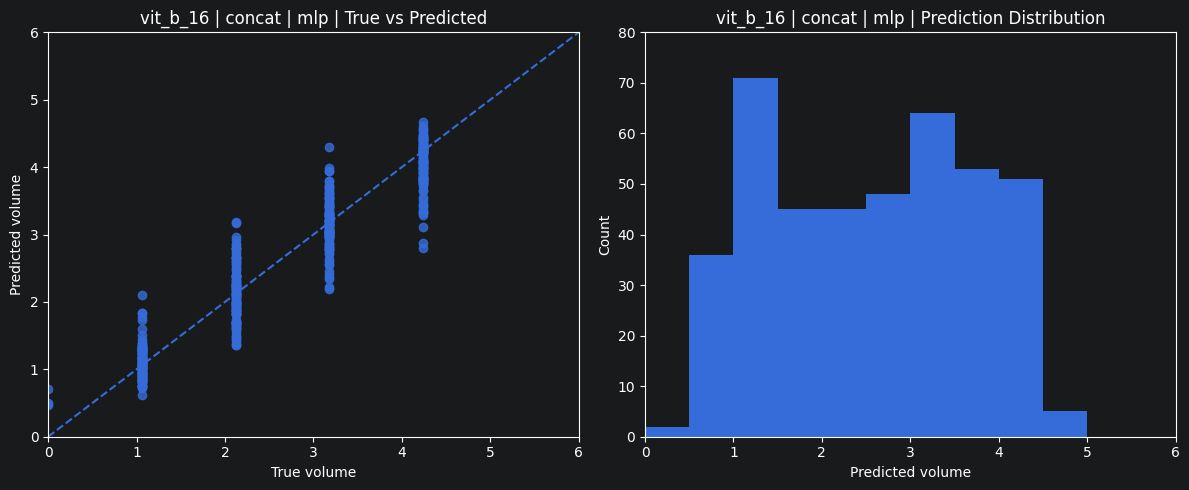

In [8]:
display(results_df)

for _, row in results_df.head(5).iterrows():
    key = (row["backbone"], row["fusion"])
    if key in nested_artifacts:
        artifact = nested_artifacts[key]
        y_true = artifact["y"]
        y_pred = artifact["oof_predictions"][row["regressor"]]
        title = f"{row['backbone']} | {row['fusion']} | {row['regressor']}"
        make_oof_plot(y_true, y_pred, title_prefix=title)

## Save Results

In [9]:
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
name = f"top_side_last_stage_unfrozen_{timestamp}.csv"
results_df.to_csv(OUTPUT_DIR / name, index=False)
print("Saved:", OUTPUT_DIR / name)

hyperparams_name = f"top_last_stage_unfrozen_best_hyperparameters_{timestamp}.json"

best_hyperparameters = {}
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    config_key = f"{backbone_name}__{fusion_name}"
    best_hyperparameters[config_key] = {}
    for regressor_name, folds in artifact["nested_results"].items():
        fold_params = [
            {
                "fold": f["fold"],
                "best_params": f["best_params"],
                "MAE": f.get("MAE"),
                "RMSE": f.get("RMSE"),
                "R2": f.get("R2"),
                "MSE": f.get("MSE"),
            }
            for f in folds
        ]

        best_hyperparameters[config_key][regressor_name] = fold_params

with open(OUTPUT_DIR / hyperparams_name, "w") as f:
    json.dump(best_hyperparameters, f, indent=2, default=str)

print("Saved:", OUTPUT_DIR / hyperparams_name)

oof_rows = []
sample_meta = samples[["file_name", "exp_id", "volume", "top_path", "side_path"]].reset_index(drop=True)

for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    for regressor_name, y_pred in artifact["oof_predictions"].items():
        y_true = artifact["y"]
        for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
            oof_rows.append({
                "backbone": backbone_name,
                "fusion": fusion_name,
                "regressor": regressor_name,
                "sample_idx": i,
                "exp_id": sample_meta.loc[i, "exp_id"],
                "top_path": sample_meta.loc[i, "top_path"],
                "side_path": sample_meta.loc[i, "side_path"],
                "volume": sample_meta.loc[i, "volume"],
                "y_true": float(yt),
                "y_pred": float(yp),
                "residual": float(yp - yt),
                "abs_error": float(abs(yp - yt)),
            })

oof_df = pd.DataFrame(oof_rows)
oof_name = f"top_side_last_stage_unfrozen_oof_predictions_{timestamp}.csv"
oof_df.to_csv(OUTPUT_DIR / oof_name, index=False)

print("Saved:", OUTPUT_DIR / oof_name)

Saved: results/top_side_last_stage_unfrozen_2026-04-05_18-36-42.csv
Saved: results/top_last_stage_unfrozen_best_hyperparameters_2026-04-05_18-36-42.json
Saved: results/top_side_last_stage_unfrozen_oof_predictions_2026-04-05_18-36-42.csv


In [10]:
import pickle
from pathlib import Path

output_path = Path("results") / f"last_stage_unfrozen_nested_artifacts_{timestamp}.pkl"

with open(output_path, "wb") as f:
    pickle.dump(nested_artifacts, f)

print("Saved:", output_path)

Saved: results/last_stage_unfrozen_nested_artifacts_2026-04-05_18-36-42.pkl
